In [5]:
pip install wfdb

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Importing packages

import os
import datetime
import wfdb
import sys
import pywt
import seaborn
import numpy as np
import tensorflow as tf
import math
import sklearn
from math import ceil
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from os.path import join as osj
import pandas as pd

In [1]:
project_path = "/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/mitdata1"

In [27]:
patient_ids = pd.read_csv(project_path + "/RECORDS", header=None).to_numpy().reshape(-1)
patient_ids

array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 111, 112, 113,
       114, 115, 116, 117, 118, 119, 121, 122, 123, 124, 200, 201, 202,
       203, 205, 207, 208, 209, 210, 212, 213, 214, 215, 217, 219, 220,
       221, 222, 223, 228, 230, 231, 232, 233, 234])

In [28]:
# Loading all patients ECG SIGNALs using for loop

def get_ecg_signals(patient_ids):
    lead0 = {}
    lead1 = {}

    for id_ in patient_ids:
        record_path = osj(project_path, str(id_))

        if not os.path.exists(record_path + ".hea"):
            continue

        signals, info = wfdb.rdsamp(record_path)
        lead0[id_] = signals[:, 0]
        lead1[id_] = signals[:, 1]

    return lead0, lead1

## **Part 2: Denoising, R-Peak Detection, Segmentation**

### **Part 2.1 : Signal Denoising**
Denoising menggunakan Discrete Wavelet Transform (DWT)

In [30]:
# User defined fucntion for DWT and reconstruction
def denoise(data):
    # wavelet transform
    coeffs = pywt.wavedec(data=data, wavelet='db5', level=9)
    cA9, cD9, cD8, cD7, cD6, cD5, cD4, cD3, cD2, cD1 = coeffs

    # Threshold denoising
    threshold = (np.median(np.abs(cD1)) / 0.6745) * (np.sqrt(2 * np.log(len(cD1))))
    cD1.fill(0)
    cD2.fill(0)
    for i in range(1, len(coeffs) - 2):
        coeffs[i] = pywt.threshold(coeffs[i], threshold)

    # Inverse wavelet transform to obtain the denoised signal
    rdata = pywt.waverec(coeffs=coeffs, wavelet='db5')
    return rdata

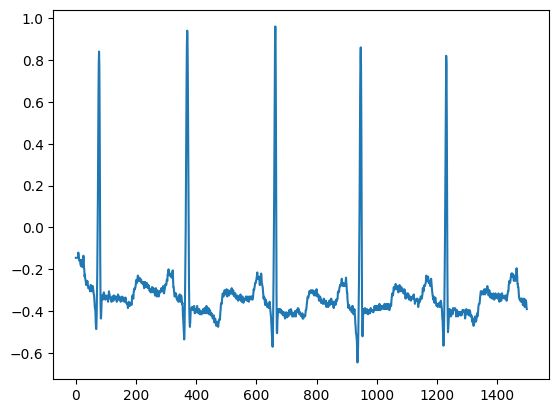

In [31]:
# Ploting a signal before denoising
sample_id = patient_ids[0]
record = wfdb.rdrecord(osj(project_path, str(sample_id)), channel_names=['MLII'])
data = record.p_signal.flatten()
plt.plot(data[0:1500])

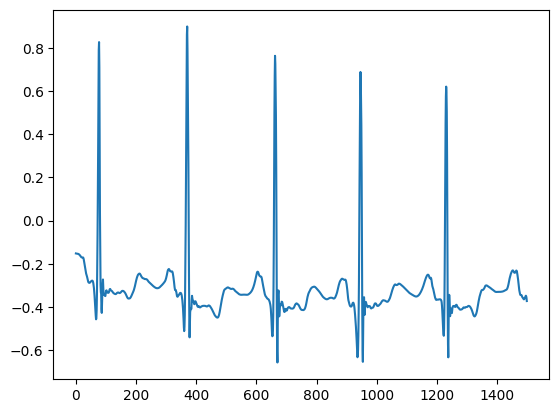

In [32]:
# Same signal after denoising
rdata = denoise(data=data)
plt.plot(rdata[0:1500])

## **Part 3: Loading Dataset**


### **Part 3.1 : Loading All Dataset from 'project_path'**

In [33]:
def getDataSet(number, X_data, Y_data):
    
    # Considering 15 types ECG heartbeats that are later grouped in 5 classes
    ecgClassSet = ['N', 'L', 'R', 'e', 'j', 'A', 'a', 'J', 'S', 'V', 'E', 'F', '/', 'f', 'Q'] 

    record_path = osj(project_path, number)

    # Reading Channel names
    _, info = wfdb.io.rdsamp(record_path)
    channels = info['sig_name']
    channel1, channel2 = channels[0], channels[1]
    print(channel1, channel2)
    
    # Read ECG data records
    print("reading " + number + " ECG data...")
    record = wfdb.rdrecord(record_path, channel_names=[channel1])
    data = record.p_signal.flatten()
    rdata = denoise(data=data)

    # Obtain the position and corresponding label of the R wave in the ECG data record
    annotation = wfdb.rdann(record_path, 'atr')
    Rlocation = annotation.sample
    Rclass = annotation.symbol

    # Unstable data before and after removal
    start = 2
    end = 3  
    i = start
    j = len(annotation.symbol) - end

    # Making labels, Y_data Convert NSVFQ in order to 0123456...14
    while i < j:
        try:
            beat_type = Rclass[i]
            lable = ecgClassSet.index(beat_type)

            if Rlocation[i] - 99 >= 0 and Rlocation[i] + 201 < len(rdata):
                x_train = rdata[Rlocation[i] - 99:Rlocation[i] + 201]
                X_data.append(x_train)
                Y_data.append(lable)

            i += 1

        except ValueError:
            i += 1

    return X_data, Y_data

In [34]:
# Load the dataset and preprocess it
def loadData():
    numberSet = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
                 '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', 
                 '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', 
                 '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', 
                 '222', '223', '228', '230', '231', '232', '233', '234'] # 48 readings
    dataSet = []
    lableSet = []
    for n in numberSet:
        # getDataSet(n, dataSet, lableSet)
        dataSet, lableSet = getDataSet(n, dataSet, lableSet)

    # Turn numpy array, scramble the order
    dataSet = np.array(dataSet).reshape(-1, 300)
    lableSet = np.array(lableSet).reshape(-1, 1)
    train_ds = np.hstack((dataSet, lableSet))
    np.random.shuffle(train_ds)

    # dataset and its label set
    X = train_ds[:, :300]
    Y = train_ds[:, 300]
    return X, Y

# Input X and Output Y data loading
X, Y = loadData()

MLII V5
reading 100 ECG data...
MLII V1
reading 101 ECG data...
V5 V2
reading 102 ECG data...
MLII V2
reading 103 ECG data...
V5 V2
reading 104 ECG data...
MLII V1
reading 105 ECG data...
MLII V1
reading 106 ECG data...
MLII V1
reading 107 ECG data...
MLII V1
reading 108 ECG data...
MLII V1
reading 109 ECG data...
MLII V1
reading 111 ECG data...
MLII V1
reading 112 ECG data...
MLII V1
reading 113 ECG data...
V5 MLII
reading 114 ECG data...
MLII V1
reading 115 ECG data...
MLII V1
reading 116 ECG data...
MLII V2
reading 117 ECG data...
MLII V1
reading 118 ECG data...
MLII V1
reading 119 ECG data...
MLII V1
reading 121 ECG data...
MLII V1
reading 122 ECG data...
MLII V5
reading 123 ECG data...
MLII V4
reading 124 ECG data...
MLII V1
reading 200 ECG data...
MLII V1
reading 201 ECG data...
MLII V1
reading 202 ECG data...
MLII V1
reading 203 ECG data...
MLII V1
reading 205 ECG data...
MLII V1
reading 207 ECG data...
MLII V1
reading 208 ECG data...
MLII V1
reading 209 ECG data...
MLII V1
read

# **Part 4: Train-Test Splitting and Class Balancing**

### **Part 4.1 : 15 Types of Heartbeats to 5 Level Conversion**
Konversi seluruh 15 jenis aritmia menjadi 5 garis besar (sesuai dengan penjelasan di awal kode)

In [35]:
train_ds = loadData()

MLII V5
reading 100 ECG data...
MLII V1
reading 101 ECG data...
V5 V2
reading 102 ECG data...
MLII V2
reading 103 ECG data...
V5 V2
reading 104 ECG data...
MLII V1
reading 105 ECG data...
MLII V1
reading 106 ECG data...
MLII V1
reading 107 ECG data...
MLII V1
reading 108 ECG data...
MLII V1
reading 109 ECG data...
MLII V1
reading 111 ECG data...
MLII V1
reading 112 ECG data...
MLII V1
reading 113 ECG data...
V5 MLII
reading 114 ECG data...
MLII V1
reading 115 ECG data...
MLII V1
reading 116 ECG data...
MLII V2
reading 117 ECG data...
MLII V1
reading 118 ECG data...
MLII V1
reading 119 ECG data...
MLII V1
reading 121 ECG data...
MLII V1
reading 122 ECG data...
MLII V5
reading 123 ECG data...
MLII V4
reading 124 ECG data...
MLII V1
reading 200 ECG data...
MLII V1
reading 201 ECG data...
MLII V1
reading 202 ECG data...
MLII V1
reading 203 ECG data...
MLII V1
reading 205 ECG data...
MLII V1
reading 207 ECG data...
MLII V1
reading 208 ECG data...
MLII V1
reading 209 ECG data...
MLII V1
read

In [41]:
X = train_ds[0]
Y = train_ds[1]

In [42]:
# 15 level to 5 level conversion
Y_5class = np.copy(Y)

for i in range(Y.shape[0]):
  # print(i)
  if 0 <= Y[i] <= 4:
    Y_5class[i] = 0
  if 5 <= Y[i] <= 8:
    Y_5class[i] = 1
  if 9 <= Y[i] <= 10:
    Y_5class[i] = 2
  if Y[i] == 11:
    Y_5class[i] = 3
  if 12 <= Y[i] <= 14:
    Y_5class[i] = 4
print('changing done')

changing done


In [44]:
from collections import Counter

Y_5class_list = list(Y_5class)
Counter(Y_5class_list)

Counter({np.float64(0.0): 90472,
         np.float64(4.0): 8027,
         np.float64(2.0): 7229,
         np.float64(1.0): 2775,
         np.float64(3.0): 802})

In [45]:
ecg_dataset = np.copy(train_ds)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 109305) + inhomogeneous part.